# **Latinoamerica comparte--Daniela Moreno, Sofia Torres, Samuel Avellaneda**

In [153]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# **Estados**


*  S0 - Sesión no iniciada
*  S1 - Formulario de login visible
*  S2 - Credenciales en ingreso
*  S3 - Autenticación fallida
*  S4 - Sesión activa - Superadmin
*  S5 - Sesión activa - Admin
*  S6 - Sesión activa - Editor
*  S7 - Sesión cerrada manualmente
*  S8 - Sesión cerrada por inactividad
*  S9 - Panel de usuarios abierto
*  S10 - Formulario de usuario en diligenciamiento
*  S11 - Usuario registrado exitosamente
*  S12 - Error al registrar usuario
*  S13 - Formulario de edición de usuario activo
*  S14 - Usuario modificado exitosamente
*  S15 - Panel de contenido por país abierto
*  S16 - Formulario de noticia en diligenciamiento
*  S17 - Noticia visible públicamente
*  S18 - Formulario de edición de noticia activo
*  S19 - Noticia eliminada
*  S20 - Formulario de testimonio en diligenciamiento
*  S21 - Testimonio visible públicamente
*  S22 - Formulario de edición de testimonio activo
*  S23 - Error al gestionar contenido
*  S24 - Detalle de noticia visible
*  S25 - Panel de solicitudes abierto
*  S26 - Detalle de solicitud visible
*  S27 - Estado de solicitud actualizado
*  S28 - Página de inicio cargada
*  S29 - Contenido general en navegación
*  S30 - Sección de noticias visible
*  S31 - Sección de testimonios visible
*  S32 - Acceso denegado por permisos
*  S33 - Chatbot iniciado
*  S34 - Consulta en procesamiento
*  S35 - Respuesta del chatbot exitosa
*  S36 - Respuesta del chatbot no disponible


# **Recorridos**

* R1 (Navegación básica del visitante) S0 → S28 → S29
* R2 (Consulta de noticias) S0 → S28 → S30
* R3 (Consulta de testimonios) S0 → S28 → S31
* R4 (Uso del chatbot con respuesta exitosa) S0 → S28 → S33 → S34 → S35
* R5 (Uso del chatbot sin respuesta disponible) S0 → S28 → S33 → S34 → S36
* R6 (Lee noticias y luego usa el chatbot) S0 → S28 → S30 → S33 → S34 → S35
* R7 (Intenta acción restringida y abandona) S0 → S28 → S32 → S0
* R8 (Navega varias secciones sin objetivo claro) S0 → S28 → S29 → S30 → S28 → S31
* R9 (Lee testimonio, intenta acción y se va) S0 → S28 → S31 → S32 → S0
* R10 (Entra, mira inicio y sale inmediatamente) S0 → S28 → S0
* R11 (Navega noticias, duda y vuelve al inicio) S0 → S28 → S30 → S28 → S0
* R12 (Chatbot sin respuesta, reintenta y lo logra) S0 → S28 → S33 → S34 → S36 → S33 → S34 → S35
* R13 (Login fallido y abandona) S0 → S1 → S2 → S3 → S0
* R14 (Múltiples intentos fallidos de login) S0 → S1 → S2 → S3 → S1 → S2 → S3
* R15 (Abre login pero regresa sin intentar) S0 → S1 → S0
* R16 (Login fallido, navega y usa chatbot) S0 → S1 → S2 → S3 → S28 → S33 → S34 → S35
* R17 (Login fallido, regresa y lo intenta de nuevo) S0 → S1 → S2 → S3 → S1 → S2 → S4 → S9
* R18 (Superadmin accede al panel de usuarios) S0 → S1 → S2 → S4 → S9
* R19 (Crea usuario exitosamente) S4 → S9 → S10 → S11
* R20 (Error al crear usuario, corrige y lo logra) S4 → S9 → S10 → S12 → S10 → S11
* R21 (Error al crear usuario y abandona) S4 → S9 → S10 → S12 → S9
* R22 (Edita usuario exitosamente) S4 → S9 → S13 → S14
* R23 (Abre edición de usuario y cancela) S4 → S9 → S13 → S9
* R24 (Revisa panel, no hace cambios y cierra sesión) S4 → S9 → S4 → S7 → S0
* R25 (Superadmin usa el chatbot desde la página pública) S4 → S28 → S33 → S34 → S35
* R26 (Crea usuario y cierra sesión) S4 → S9 → S10 → S11 → S7 → S0
* R27 (Admin accede al panel de contenido) S0 → S1 → S2 → S5 → S15
* R28 (Crea y publica noticia exitosamente) S5 → S15 → S16 → S17
* R29 (Error al crear noticia y abandona) S5 → S15 → S16 → S23 → S0
* R30 (Error al crear noticia, corrige y publica) S5 → S15 → S16 → S23 → S16 → S17
* R31 (Edita noticia existente) S5 → S15 → S18 → S17
* R32 (Elimina una noticia) S5 → S15 → S19
* R33 (Revisa detalle de noticia y vuelve al panel) S5 → S15 → S24 → S15
* R34 (Gestiona solicitud completa) S5 → S25 → S26 → S27
* R35 (Revisa solicitud y cierra sesión) S5 → S25 → S26 → S27 → S7 → S0
* R36 (Admin intenta acción no permitida) S5 → S28 → S32 → S0
* R37 (Admin publica noticia y cierra sesión) S5 → S15 → S16 → S17 → S7 → S0
* R38 (Admin usa chatbot y navega contenido) S5 → S28 → S33 → S34 → S35 → S29
* R39 (Admin chatbot sin respuesta y regresa) S5 → S28 → S33 → S34 → S36 → S29
* R40 (Editor accede al panel de contenido) S0 → S1 → S2 → S6 → S15
* R41 (Edita testimonio exitosamente) S6 → S15 → S22 → S21
* R42 (Crea testimonio nuevo) S6 → S15 → S20 → S21
* R43 (Publica noticia nueva) S6 → S15 → S16 → S17
* R44 (Error al editar noticia, corrige y publica) S6 → S15 → S18 → S23 → S18 → S17
* R45 (Error al editar noticia y abandona) S6 → S15 → S18 → S23 → S15
* R46 (Abre edición de noticia y cancela sin guardar) S6 → S15 → S18 → S15 → S0
* R47 (Editor intenta acción no permitida) S6 → S28 → S32 → S0
* R48 (Editor usa chatbot y navega contenido) S6 → S28 → S33 → S34 → S35 → S29
* R49 (Edita testimonio y cierra sesión) S6 → S15 → S22 → S21 → S7 → S0
* R50 (Flujo completo del editor) S0 → S1 → S2 → S6 → S15 → S18 → S17 → S7 → S0
* R51 (Visitante lee noticias, ve testimonios y usa chatbot) S0 → S28 → S30 → S31 → S33 → S34 → S35 → S0
* R52 (Login fallido, navega y se va) S0 → S1 → S2 → S3 → S28 → S29 → S0
* R53 (Admin edita noticia, duda y vuelve al panel) S5 → S15 → S18 → S15 → S16 → S17
* R54 (Editor crea testimonio, navega y cierra sesión) S6 → S15 → S20 → S21 → S28 → S31 → S7 → S0
* R55 (Visitante explora, intenta acción, usa chatbot y sale) S0 → S28 → S29 → S32 → S33 → S34 → S35 → S0
* R56 (Superadmin crea usuario, error y crea otro) S4 → S9 → S10 → S12 → S10 → S11 → S9 → S10 → S11
* R57 (Admin gestiona solicitud y luego edita noticia) S5 → S25 → S26 → S27 → S15 → S18 → S17
* R58 (Editor publica noticia, navega el resultado y sale) S6 → S15 → S16 → S17 → S28 → S30 → S7 → S0
* R59 (Visitante usa chatbot sin respuesta y se va) S0 → S28 → S33 → S34 → S36 → S0
* R60 (Admin revisa noticia, la edita y publica) S5 → S15 → S24 → S15 → S18 → S17 → S7 → S0
* R61 (Editor edita testimonio, error y reintenta) S6 → S15 → S22 → S23 → S22 → S21

In [154]:
recorridos = [
    ["S0","S28","S29"],
    ["S0","S28","S30"],
    ["S0","S28","S31"],
    ["S0","S28","S33","S34","S35"],
    ["S0","S28","S33","S34","S36"],
    ["S0","S28","S30","S33","S34","S35"],
    ["S0","S28","S32","S0"],
    ["S0","S28","S29","S30","S28","S31"],
    ["S0","S28","S31","S32","S0"],
    ["S0","S28","S0"],
    ["S0","S28","S30","S28","S0"],
    ["S0","S28","S33","S34","S36","S33","S34","S35"],
    ["S0","S1","S2","S3","S0"],
    ["S0","S1","S2","S3","S1","S2","S3"],
    ["S0","S1","S0"],
    ["S0","S1","S2","S3","S28","S33","S34","S35"],
    ["S0","S1","S2","S3","S1","S2","S4","S9"],
    ["S0","S1","S2","S4","S9"],
    ["S4","S9","S10","S11"],
    ["S4","S9","S10","S12","S10","S11"],
    ["S4","S9","S10","S12","S9"],
    ["S4","S9","S13","S14"],
    ["S4","S9","S13","S9"],
    ["S4","S9","S4","S7","S0"],
    ["S4","S28","S33","S34","S35"],
    ["S4","S9","S10","S11","S7","S0"],
    ["S0","S1","S2","S5","S15"],
    ["S5","S15","S16","S17"],
    ["S5","S15","S16","S23","S0"],
    ["S5","S15","S16","S23","S16","S17"],
    ["S5","S15","S18","S17"],
    ["S5","S15","S19"],
    ["S5","S15","S24","S15"],
    ["S5","S25","S26","S27"],
    ["S5","S25","S26","S27","S7","S0"],
    ["S5","S28","S32","S0"],
    ["S5","S15","S16","S17","S7","S0"],
    ["S5","S28","S33","S34","S35","S29"],
    ["S5","S28","S33","S34","S36","S29"],
    ["S0","S1","S2","S6","S15"],
    ["S6","S15","S22","S21"],
    ["S6","S15","S20","S21"],
    ["S6","S15","S16","S17"],
    ["S6","S15","S18","S23","S18","S17"],
    ["S6","S15","S18","S23","S15"],
    ["S6","S15","S18","S15","S0"],
    ["S6","S28","S32","S0"],
    ["S6","S28","S33","S34","S35","S29"],
    ["S6","S15","S22","S21","S7","S0"],
    ["S0","S1","S2","S6","S15","S18","S17","S7","S0"],
    ["S0","S28","S30","S31","S33","S34","S35","S0"],
    ["S0","S1","S2","S3","S28","S29","S0"],
    ["S5","S15","S18","S15","S16","S17"],
    ["S6","S15","S20","S21","S28","S31","S7","S0"],
    ["S0","S28","S29","S32","S33","S34","S35","S0"],
    ["S4","S9","S10","S12","S10","S11","S9","S10","S11"],
    ["S5","S25","S26","S27","S15","S18","S17"],
    ["S6","S15","S16","S17","S28","S30","S7","S0"],
    ["S0","S28","S33","S34","S36","S0"],
    ["S5","S15","S24","S15","S18","S17","S7","S0"],
    ["S6","S15","S22","S23","S22","S21"],
]

### **Definición de Recorridos de Usuario**
Aquí definimos todos los posibles caminos o 'recorridos' que un usuario puede tomar a través de los diferentes estados del sistema. Cada recorrido es una secuencia de estados, por ejemplo, `S0` (Sesión no iniciada) a `S28` (Página de inicio cargada) y luego a `S29` (Contenido general en navegación).

In [155]:
estados = [
    "S0", "S1", "S2", "S3", "S4", "S5", "S6", "S7", "S8",
    "S9", "S10", "S11", "S12", "S13", "S14", "S15", "S16",
    "S17", "S18", "S19", "S20", "S21", "S22", "S23", "S24",
    "S25", "S26", "S27", "S28", "S29", "S30", "S31", "S32",
    "S33", "S34", "S35", "S36"
]

### **Creación de la Matriz de Conteos de Transiciones**
Vamos a construir una tabla (matriz) donde cada celda indica cuántas veces un usuario pasó de un estado (`estado_actual`) a otro (`estado_siguiente`). Empezamos con una tabla llena de ceros y luego contamos las transiciones observadas en nuestros `recorridos` definidos.

In [156]:
# Primero, preparamos una tabla vacía (matriz) donde contaremos cuántas veces
# los usuarios pasan de un estado a otro. Todas las casillas empiezan en cero.
matriz_conteos = pd.DataFrame(0, index=estados, columns=estados)

# Ahora, analizamos cada recorrido que definimos. Para cada paso en un recorrido,
# aumentamos el contador en nuestra tabla para la transición específica
# (de 'estado_actual' a 'estado_siguiente').
for recorrido in recorridos:
    for i in range(len(recorrido) - 1):
        estado_actual   = recorrido[i]
        estado_siguiente = recorrido[i + 1]
        matriz_conteos.loc[estado_actual, estado_siguiente] += 1

matriz_conteos

,S0,S1,S2,S3,S4,S5,S6,S7,S8,S9,...,S27,S28,S29,S30,S31,S32,S33,S34,S35,S36
S0,0,10,0,0,0,0,0,0,0,0,...,0,15,0,0,0,0,0,0,0,0
S1,1,0,11,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
S2,0,0,0,6,2,1,2,0,0,0,...,0,0,0,0,0,0,0,0,0,0
S3,1,2,0,0,0,0,0,0,0,0,...,0,2,0,0,0,0,0,0,0,0
S4,0,0,0,0,0,0,0,1,0,10,...,0,1,0,0,0,0,0,0,0,0
S5,0,0,0,0,0,0,0,0,0,0,...,0,3,0,0,0,0,0,0,0,0
S6,0,0,0,0,0,0,0,0,0,0,...,0,2,0,0,0,0,0,0,0,0
S7,9,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
S8,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
S9,0,0,0,0,1,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


### **Cálculo de la Matriz de Probabilidades de Transición**
Ahora, convertiremos los conteos de transiciones en probabilidades. Esto nos dirá, por ejemplo, si un usuario está en `S0`, cuál es la probabilidad de que vaya a `S1` o `S28`. Simplemente dividimos cada conteo por el total de salidas de ese estado. Si un estado no tiene salidas, le asignamos probabilidad 0.

In [157]:
# Para saber la probabilidad de ir de un estado a otro, tomamos nuestra tabla de conteos.
# Por cada estado de origen, dividimos sus conteos por el total de veces que los usuarios
# salieron de ese estado. Así, cada fila sumará 1, representando el 100% de las posibilidades
# desde ese estado. Si un estado no tiene salidas (un estado final), su probabilidad de
# ir a cualquier otro estado será 0.
matriz_probabilidades = matriz_conteos.div(
    matriz_conteos.sum(axis=1),  # Sumamos por filas para saber el total de salidas de cada estado
    axis=0                       # Aplicamos esta división a cada fila
).fillna(0)                      # Si un estado no tiene salidas, rellenamos con 0 para que no haya errores.

matriz_probabilidades

,S0,S1,S2,S3,S4,S5,S6,S7,S8,S9,...,S27,S28,S29,S30,S31,S32,S33,S34,S35,S36
S0,0.000000,0.4,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.000000,...,0.0,0.600000,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.000000,0.000000
S1,0.083333,0.0,0.916667,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.000000,...,0.0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.000000,0.000000
S2,0.000000,0.0,0.000000,0.545455,0.181818,0.090909,0.181818,0.000000,0.0,0.000000,...,0.0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.000000,0.000000
S3,0.200000,0.4,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.000000,...,0.0,0.400000,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.000000,0.000000
S4,0.000000,0.0,0.000000,0.000000,0.000000,0.000000,0.000000,0.083333,0.0,0.833333,...,0.0,0.083333,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.000000,0.000000
S5,0.000000,0.0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.000000,...,0.0,0.187500,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.000000,0.000000
S6,0.000000,0.0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.000000,...,0.0,0.142857,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.000000,0.000000
S7,1.000000,0.0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.000000,...,0.0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.000000,0.000000
S8,0.000000,0.0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.000000,...,0.0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.000000,0.000000
S9,0.000000,0.0,0.000000,0.000000,0.111111,0.000000,0.000000,0.000000,0.0,0.000000,...,0.0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.000000,0.000000


### **Definición de Estados Finales y Función de Simulación**
Aquí establecemos qué estados consideramos como 'finales' en un recorrido de usuario (por ejemplo, cuando se cierra sesión o se completa una acción). También creamos una función que simulará el comportamiento de un usuario, moviéndose de estado en estado según las probabilidades que calculamos, hasta que llegue a un estado final o se agoten los pasos.

In [158]:
estados_finales = [
    'S3',   # Autenticación fallida
    'S7',   # Sesión cerrada manualmente
    'S8',   # Sesión cerrada por inactividad
    'S11',  # Usuario registrado exitosamente
    'S12',  # Error al registrar usuario
    'S14',  # Usuario modificado exitosamente
    'S17',  # Noticia visible públicamente
    'S19',  # Noticia eliminada
    'S21',  # Testimonio visible públicamente
    'S23',  # Error al gestionar contenido
    'S27',  # Estado de solicitud actualizado
    'S29',  # Contenido general en navegación
    'S30',  # Sección de noticias visible
    'S32',  # Acceso denegado por permisos
    'S35',  # Respuesta del chatbot exitosa
    'S36',  # Respuesta del chatbot no disponible
]
print(estados_finales)

# Esta función simula el camino de un usuario a través de nuestro sistema.
# Recibe la tabla de probabilidades, un estado de inicio (por defecto 'S0')
# y un número máximo de pasos para evitar bucles infinitos.
def simular_usuario(matriz_probabilidades, estado_inicial='S0', max_pasos=50):
    estado_actual = estado_inicial
    recorrido = [estado_actual] # Empezamos el recorrido con el estado inicial

    # Repetimos los pasos hasta que el usuario llegue a un estado final o exceda los pasos
    for _ in range(max_pasos):
        # Si el usuario ya está en un estado final, terminamos el recorrido
        if estado_actual in estados_finales:
            break

        # Obtenemos las probabilidades de ir a otros estados desde el estado actual
        probabilidades = matriz_probabilidades.loc[estado_actual]

        # Si no hay forma de salir de este estado (suma de probabilidades es 0), también terminamos
        if probabilidades.sum() == 0:
            break

        # Elegimos el siguiente estado basándonos en las probabilidades
        siguiente_estado = np.random.choice(
            matriz_probabilidades.columns,
            p=probabilidades.values
        )

        recorrido.append(siguiente_estado) # Añadimos el nuevo estado al recorrido
        estado_actual = siguiente_estado   # Actualizamos el estado actual

    return recorrido # Devolvemos la secuencia de estados que siguió el usuario

['S3', 'S7', 'S8', 'S11', 'S12', 'S14', 'S17', 'S19', 'S21', 'S23', 'S27', 'S29', 'S30', 'S32', 'S35', 'S36']


### **Simulación de un Recorrido Individual**
Para entender cómo funciona la simulación, ejecutamos nuestra función `simular_usuario` una vez. Esto nos muestra un ejemplo de un camino que podría tomar un usuario en nuestro sistema, empezando desde `S0`.

In [159]:
# Simular un usuario
recorrido_simulado = simular_usuario(matriz_probabilidades)

# Mostrar el recorrido
print(" → ".join(recorrido_simulado))

S0 → S1 → S2 → S3


### **Ejecución de Múltiples Simulaciones**
Ahora, para tener una idea más robusta del comportamiento general, vamos a simular 1000 veces el recorrido de diferentes usuarios. Guardamos cada recorrido, su estado final y el número de pasos tomados para poder analizarlos después.

In [160]:
resultados = []

# Aquí, vamos a ejecutar nuestra simulación 1000 veces para tener una buena muestra
# de cómo los usuarios navegan por el sistema. Cada vez, registramos el camino completo
# del usuario, dónde terminó y cuántos pasos le tomó.
for i in range(1000):
    recorrido   = simular_usuario(matriz_probabilidades)
    estado_final = recorrido[-1]

    resultados.append({
        "usuario":      i + 1,
        "recorrido":    " → ".join(recorrido),
        "estado_final": estado_final,
        "num_pasos":    len(recorrido)
    })

df_resultados = pd.DataFrame(resultados)
df_resultados.head()

,usuario,recorrido,estado_final,num_pasos
0,1,S0 → S28 → S0 → S28 → S31 → S7,S7,6
1,2,S0 → S28 → S31 → S32,S32,4
2,3,S0 → S28 → S31 → S32,S32,4
3,4,S0 → S28 → S30,S30,3
4,5,S0 → S1 → S2 → S6 → S28 → S33 → S34 → S35,S35,8


### **Análisis de Resultados de la Simulación**
En este paso, hacemos que los códigos de estado (como `S0`, `S1`, etc.) sean más fáciles de entender al mapearlos a sus nombres descriptivos. También verificamos si hubo algún recorrido que no terminó en uno de nuestros estados 'finales' definidos.

In [161]:
nombres_estados = {
    "S0": "Sesión no iniciada",
    "S1": "Formulario de login visible",
    "S2": "Credenciales en ingreso",
    "S3": "Autenticación fallida",
    "S4": "Sesión activa - Superadmin",
    "S5": "Sesión activa - Admin",
    "S6": "Sesión activa - Editor",
    "S7": "Sesión cerrada manualmente",
    "S8": "Sesión cerrada por inactividad",
    "S9": "Panel de usuarios abierto",
    "S10": "Formulario de usuario en diligenciamiento",
    "S11": "Usuario registrado exitosamente",
    "S12": "Error al registrar usuario",
    "S13": "Formulario de edición de usuario activo",
    "S14": "Usuario modificado exitosamente",
    "S15": "Panel de contenido por país abierto",
    "S16": "Formulario de noticia en diligenciamiento",
    "S17": "Noticia visible públicamente",
    "S18": "Formulario de edición de noticia activo",
    "S19": "Noticia eliminada",
    "S20": "Formulario de testimonio en diligenciamiento",
    "S21": "Testimonio visible públicamente",
    "S22": "Formulario de edición de testimonio activo",
    "S23": "Error al gestionar contenido",
    "S24": "Detalle de noticia visible",
    "S25": "Panel de solicitudes abierto",
    "S26": "Detalle de solicitud visible",
    "S27": "Estado de solicitud actualizado",
    "S28": "Página de inicio cargada",
    "S29": "Contenido general en navegación",
    "S30": "Sección de noticias visible",
    "S31": "Sección de testimonios visible",
    "S32": "Acceso denegado por permisos",
    "S33": "Chatbot iniciado",
    "S34": "Consulta en procesamiento",
    "S35": "Respuesta del chatbot exitosa",
    "S36": "Respuesta del chatbot no disponible"
}

df_resultados["resultado"] = df_resultados["estado_final"].map(nombres_estados)

df_resultados.head()

# También revisamos si hubo algún recorrido que no terminó en uno de nuestros estados 'finales' definidos.
# Esto nos ayuda a identificar si hay rutas inesperadas o si necesitamos añadir más estados finales.
df_resultados["truncado"] = df_resultados.apply(
    lambda row: row["estado_final"] not in estados_finales, axis=1
)
print("Recorridos truncados:", df_resultados["truncado"].sum(), "de 1000")
print(df_resultados[df_resultados["truncado"] == True]["estado_final"].value_counts())

Recorridos truncados: 0 de 1000
Series([], Name: count, dtype: int64)


### **Frecuencia Relativa de los Resultados Finales**
Para entender qué acciones completan más los usuarios, calculamos el porcentaje de veces que cada estado final fue alcanzado. Esto nos da una visión clara de los resultados más comunes de las interacciones de los usuarios.

In [162]:
# Aquí calculamos qué tan seguido aparece cada resultado final.
# Esto nos muestra en porcentaje cuál es el destino más común de los usuarios.
porcentajes = df_resultados["resultado"].value_counts(normalize=True) * 100

print(porcentajes.round(1))

resultado
Autenticación fallida                  22.1
Respuesta del chatbot exitosa          15.7
Sección de noticias visible            13.5
Contenido general en navegación        11.2
Acceso denegado por permisos           10.8
Respuesta del chatbot no disponible     7.0
Usuario registrado exitosamente         4.1
Sesión cerrada manualmente              3.7
Noticia visible públicamente            3.4
Error al gestionar contenido            2.4
Testimonio visible públicamente         2.0
Error al registrar usuario              1.7
Usuario modificado exitosamente         1.1
Noticia eliminada                       0.7
Estado de solicitud actualizado         0.6
Name: proportion, dtype: float64


### **Visualización de los Resultados Finales**
Finalmente, creamos un gráfico de barras para visualizar de manera sencilla la distribución de los resultados finales. De esta forma, podemos ver rápidamente cuáles son los estados más frecuentes donde terminan las sesiones simuladas de los usuarios.

/tmp/ipykernel_17807/4000918872.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=conteo.index, y=conteo.values, palette='coolwarm')


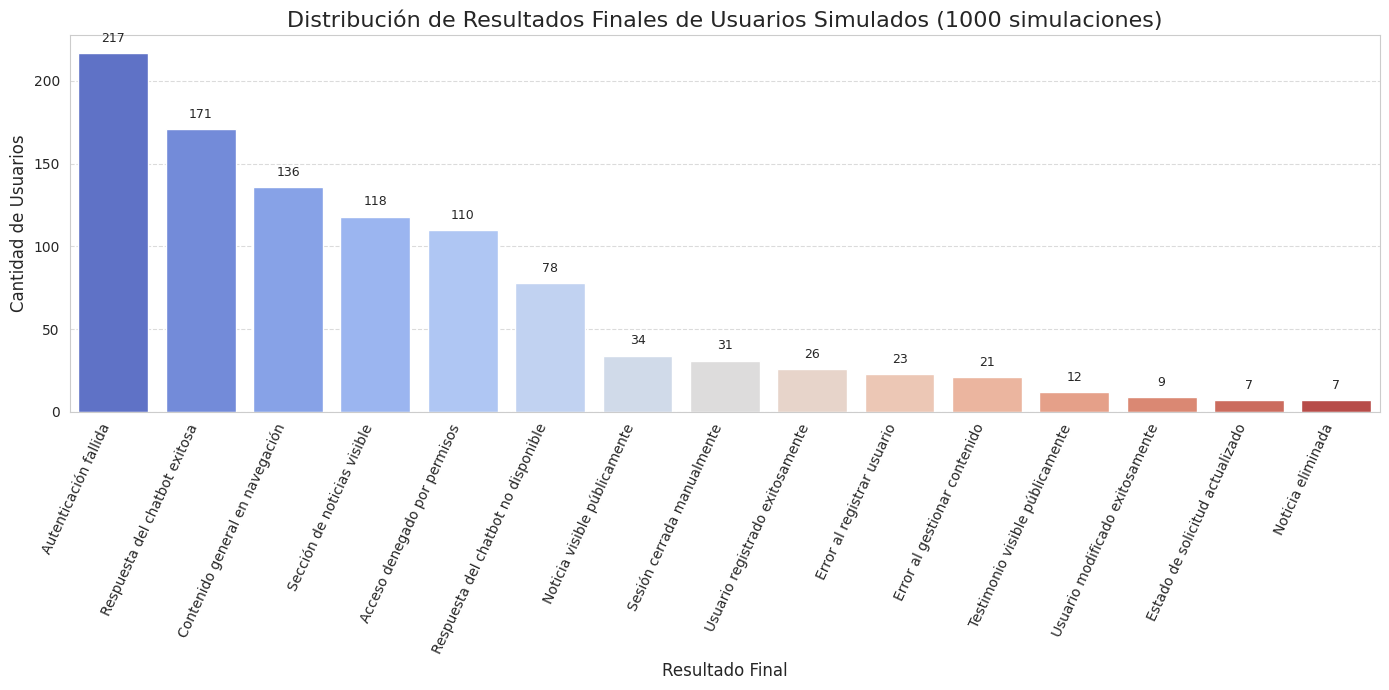

In [163]:
plt.figure(figsize=(14, 7))
sns.barplot(x=conteo.index, y=conteo.values, palette='coolwarm')

plt.title('Distribución de Resultados Finales de Usuarios Simulados (1000 simulaciones)', fontsize=16)
plt.xlabel('Resultado Final', fontsize=12)
plt.ylabel('Cantidad de Usuarios', fontsize=12)

plt.xticks(rotation=65, ha='right', fontsize=10)
plt.yticks(fontsize=10)
plt.grid(axis='y', linestyle='--', alpha=0.7)

# Añadir etiquetas de datos
for index, value in enumerate(conteo.values):
    plt.text(index, value + 5, str(value), ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.show()

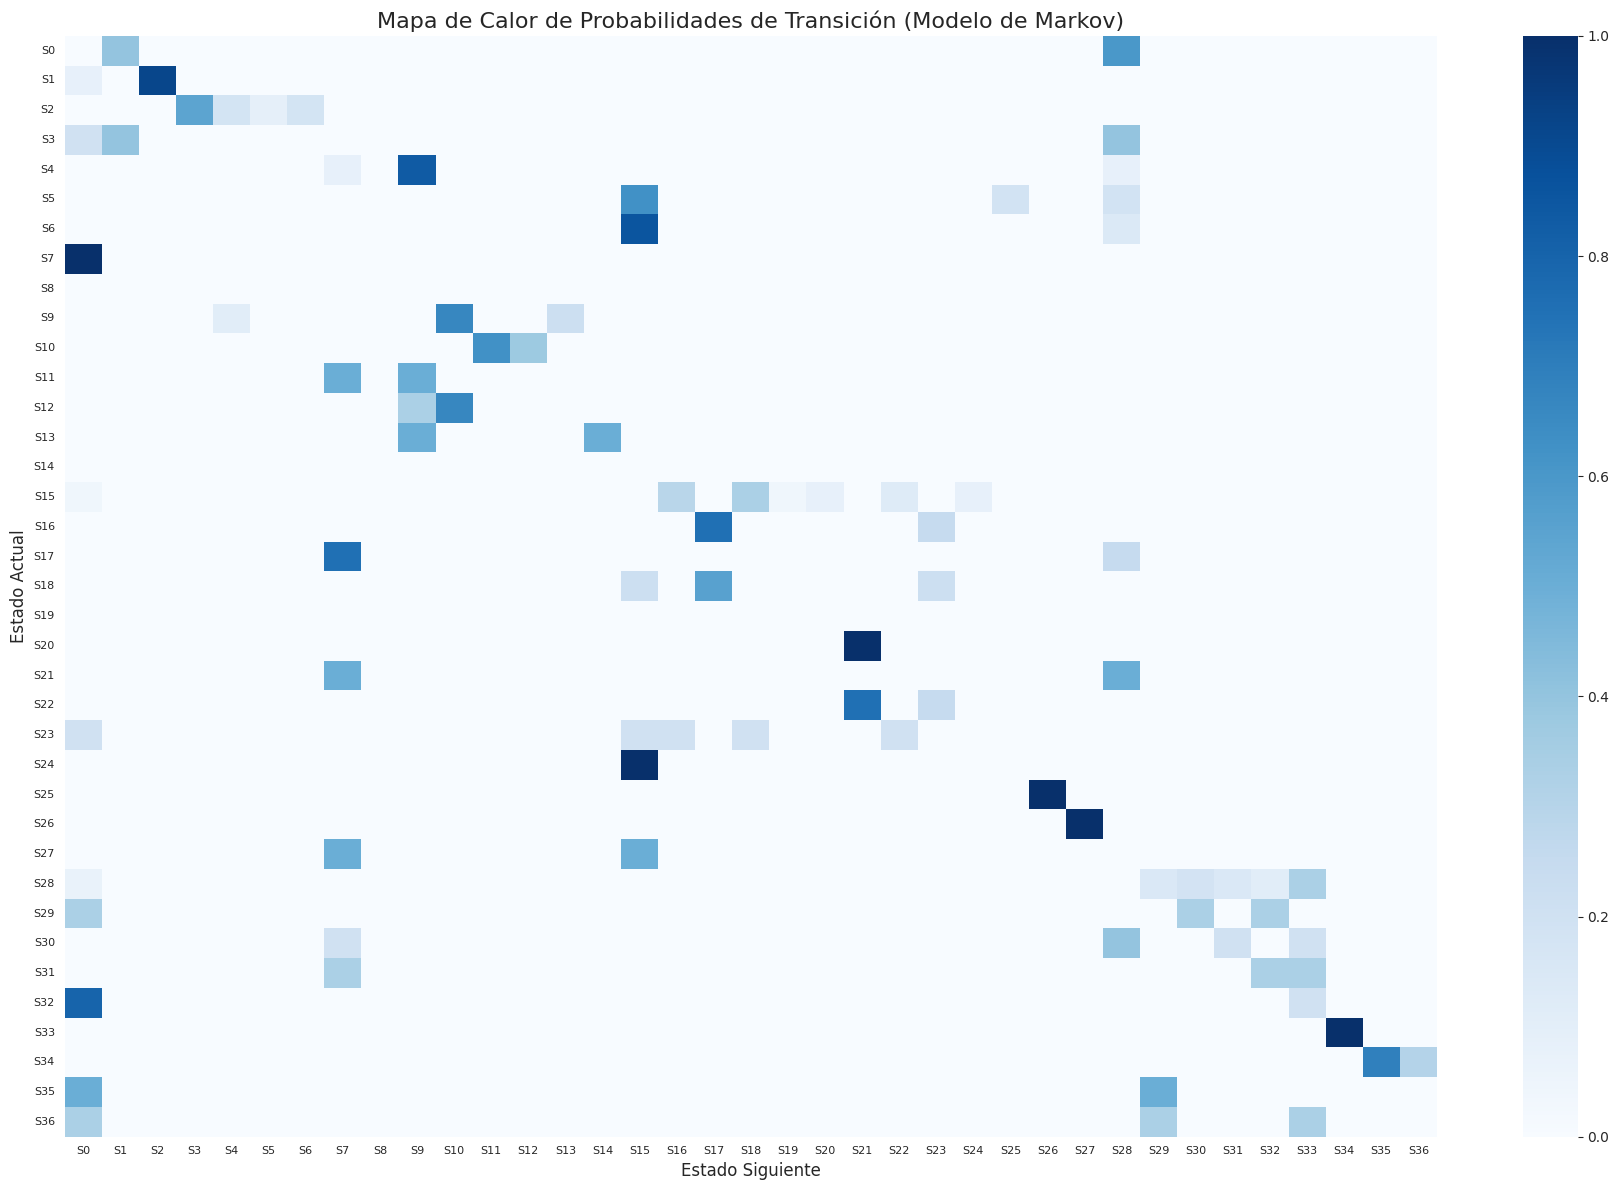

In [164]:
import seaborn as sns

# Visualización de la Matriz de Transición para validar el modelo de Markov
plt.figure(figsize=(18, 12))
sns.heatmap(matriz_probabilidades, annot=False, cmap='Blues')
plt.title('Mapa de Calor de Probabilidades de Transición (Modelo de Markov)', fontsize=16)
plt.xlabel('Estado Siguiente', fontsize=12)
plt.ylabel('Estado Actual', fontsize=12)
plt.xticks(fontsize=8)
plt.yticks(fontsize=8)
plt.tight_layout()
plt.show()

### **Análisis de Categorías de Resultados Finales**



### **Definición de Pesos para Estados de Éxito, Error y Abandono**

Para calcular un porcentaje ponderado de **Éxito**, **Error** y **Abandono**, asigne un peso a cada estado final dentro de su categoría correspondiente. Los pesos deben ser valores decimales entre 0 y 1, donde la suma de los pesos de los estados dentro de una misma categoría debe ser igual a 1 (o 100%).

Por ejemplo, si para la categoría 'Error' considera que 'Autenticación fallida' (S3) es más crítico que 'Error al registrar usuario' (S12), puede asignarle un peso mayor. Si no se especifican pesos, el sistema asumirá que todos los estados dentro de una categoría tienen el mismo peso.

In [165]:
# Define los pesos para cada estado final dentro de sus categorías.
# La suma de los pesos dentro de cada diccionario debe ser 1.0 (o 100%).

weighted_success_states = {
    "Estado de solicitud actualizado": 0.1,      # S27
    "Contenido general en navegación": 0.1,       # S29
    "Sección de noticias visible": 0.1,          # S30
    "Respuesta del chatbot exitosa": 0.15,        # S35
    "Noticia visible públicamente": 0.15,         # S17
    "Testimonio visible públicamente": 0.15,      # S21
    "Usuario registrado exitosamente": 0.1,       # S11
    "Usuario modificado exitosamente": 0.05,      # S14
    "Noticia eliminada": 0.1                     # S19
}

weighted_error_states = {
    "Autenticación fallida": 0.4,                 # S3
    "Acceso denegado por permisos": 0.2,          # S32
    "Error al registrar usuario": 0.15,           # S12
    "Error al gestionar contenido": 0.15,         # S23
    "Respuesta del chatbot no disponible": 0.1    # S36
}

weighted_abandonment_states = {
    "Sesión cerrada manualmente": 0.6,             # S7
    "Sesión cerrada por inactividad": 0.4          # S8
}

print("Pesos definidos para Éxito:", weighted_success_states)
print("Pesos definidos para Error:", weighted_error_states)
print("Pesos definidos para Abandono:", weighted_abandonment_states)

Pesos definidos para Éxito: {'Estado de solicitud actualizado': 0.1, 'Contenido general en navegación': 0.1, 'Sección de noticias visible': 0.1, 'Respuesta del chatbot exitosa': 0.15, 'Noticia visible públicamente': 0.15, 'Testimonio visible públicamente': 0.15, 'Usuario registrado exitosamente': 0.1, 'Usuario modificado exitosamente': 0.05, 'Noticia eliminada': 0.1}
Pesos definidos para Error: {'Autenticación fallida': 0.4, 'Acceso denegado por permisos': 0.2, 'Error al registrar usuario': 0.15, 'Error al gestionar contenido': 0.15, 'Respuesta del chatbot no disponible': 0.1}
Pesos definidos para Abandono: {'Sesión cerrada manualmente': 0.6, 'Sesión cerrada por inactividad': 0.4}


In [166]:
success_final_states = [
    "Estado de solicitud actualizado",       # S27
    "Contenido general en navegación",        # S29
    "Sección de noticias visible",           # S30
    "Respuesta del chatbot exitosa",         # S35
    "Noticia visible públicamente",          # S17
    "Testimonio visible públicamente",       # S21
    "Usuario registrado exitosamente",       # S11
    "Usuario modificado exitosamente",       # S14
    "Noticia eliminada"                      # S19
]

error_final_states = [
    "Autenticación fallida",                 # S3
    "Acceso denegado por permisos",          # S32
    "Error al registrar usuario",            # S12
    "Error al gestionar contenido",          # S23
    "Respuesta del chatbot no disponible"    # S36
]

abandonment_final_states = [
    "Sesión cerrada manualmente",             # S7
    "Sesión cerrada por inactividad"          # S8
]

# Crear una nueva columna para la categoría del resultado
def classify_result(result_name):
    if result_name in success_final_states:
        return 'Éxito'
    elif result_name in error_final_states:
        return 'Error'
    elif result_name in abandonment_final_states:
        return 'Abandono'
    else:
        return 'Otro'

df_resultados['categoria_final'] = df_resultados['resultado'].apply(classify_result)

# Calcular porcentajes por categoría
porcentajes_categorias = df_resultados['categoria_final'].value_counts(normalize=True) * 100

print("Porcentajes de resultados finales por categoría:")
print(porcentajes_categorias.round(1))


Porcentajes de resultados finales por categoría:
categoria_final
Éxito       52.3
Error       44.0
Abandono     3.7
Name: proportion, dtype: float64


Porcentajes ponderados de resultados finales por categoría:
Éxito: 30.0%
Error: 59.3%
Abandono: 10.7%


/tmp/ipykernel_17807/480785689.py:32: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=categorias_ponderadas.index, y=categorias_ponderadas.values, palette=['#66c2a5', '#fc8d62', '#8da0cb'])


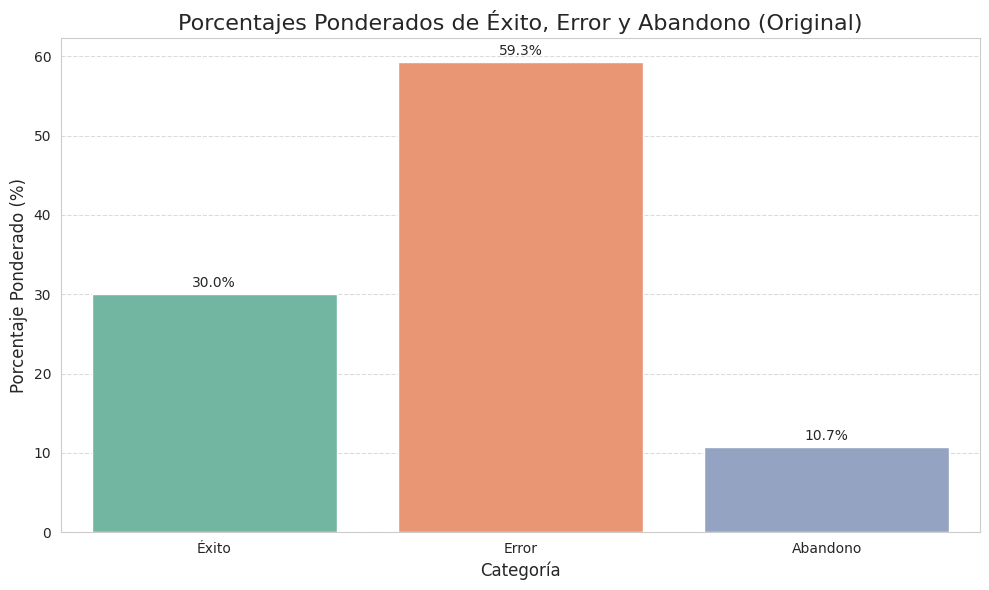

In [167]:
# Función para calcular la puntuación ponderada para cada categoría
def calculate_weighted_category_score(df_results, weighted_states_dict, category_name):
    score = 0
    for state, weight in weighted_states_dict.items():
        # Obtener el número de veces que este estado final ocurrió
        state_count = df_results[df_results['resultado'] == state].shape[0]
        score += (state_count * weight)
    return score

# Calcular las puntuaciones ponderadas
weighted_success_score = calculate_weighted_category_score(df_resultados, weighted_success_states, 'Éxito')
weighted_error_score = calculate_weighted_category_score(df_resultados, weighted_error_states, 'Error')
weighted_abandonment_score = calculate_weighted_category_score(df_resultados, weighted_abandonment_states, 'Abandono')

# Suma total de las puntuaciones para normalizar
total_weighted_score = weighted_success_score + weighted_error_score + weighted_abandonment_score

# Calcular los porcentajes finales
weighted_percentages = {
    'Éxito': (weighted_success_score / total_weighted_score) * 100 if total_weighted_score > 0 else 0,
    'Error': (weighted_error_score / total_weighted_score) * 100 if total_weighted_score > 0 else 0,
    'Abandono': (weighted_abandonment_score / total_weighted_score) * 100 if total_weighted_score > 0 else 0
}

print("Porcentajes ponderados de resultados finales por categoría:")
for category, percentage in weighted_percentages.items():
    print(f"{category}: {percentage:.1f}%")

categorias_ponderadas = pd.Series(weighted_percentages)

plt.figure(figsize=(10, 6))
sns.barplot(x=categorias_ponderadas.index, y=categorias_ponderadas.values, palette=['#66c2a5', '#fc8d62', '#8da0cb'])
plt.title('Porcentajes Ponderados de Éxito, Error y Abandono (Original)', fontsize=16)
plt.xlabel('Categoría', fontsize=12)
plt.ylabel('Porcentaje Ponderado (%)', fontsize=12)
plt.xticks(rotation=0, fontsize=10)
plt.yticks(fontsize=10)
plt.grid(axis='y', linestyle='--', alpha=0.7)

# Añadir etiquetas de datos
for index, value in enumerate(categorias_ponderadas.values):
    plt.text(index, value + 0.5, f'{value:.1f}%', ha='center', va='bottom', fontsize=10)

plt.tight_layout()
plt.show()

### **Detalle de Estados de Fallo**

En esta tabla desglosamos los estados que pertenecen a la categoría de **Error**, mostrando su frecuencia absoluta y relativa en la simulación de 1000 usuarios.

In [168]:
# Filtrar solo los resultados que están en la categoría de Error
df_errores = df_resultados[df_resultados['categoria_final'] == 'Error']

# Contar frecuencias
tabla_errores = df_errores['resultado'].value_counts().reset_index()
tabla_errores.columns = ['Estado de Fallo', 'Frecuencia (Usuarios)']

# Calcular porcentaje respecto al total de la simulación (1000)
tabla_errores['% del Total'] = (tabla_errores['Frecuencia (Usuarios)'] / 1000) * 100

display(tabla_errores)

,Estado de Fallo,Frecuencia (Usuarios),% del Total
0,Autenticación fallida,221,22.1
1,Acceso denegado por permisos,108,10.8
2,Respuesta del chatbot no disponible,70,7.0
3,Error al gestionar contenido,24,2.4
4,Error al registrar usuario,17,1.7


### **Detalle de Estados de Éxito**

Desglose de los estados que representan un flujo completado satisfactoriamente, mostrando su peso dentro del total de la simulación.

In [169]:
# Filtrar solo los resultados que están en la categoría de Éxito
df_exitos = df_resultados[df_resultados['categoria_final'] == 'Éxito']

# Contar frecuencias
tabla_exitos = df_exitos['resultado'].value_counts().reset_index()
tabla_exitos.columns = ['Estado de Éxito', 'Frecuencia (Usuarios)']

# Calcular porcentaje respecto al total de la simulación (1000)
tabla_exitos['% del Total'] = (tabla_exitos['Frecuencia (Usuarios)'] / 1000) * 100

display(tabla_exitos)

,Estado de Éxito,Frecuencia (Usuarios),% del Total
0,Respuesta del chatbot exitosa,157,15.7
1,Sección de noticias visible,135,13.5
2,Contenido general en navegación,112,11.2
3,Usuario registrado exitosamente,41,4.1
4,Noticia visible públicamente,34,3.4
5,Testimonio visible públicamente,20,2.0
6,Usuario modificado exitosamente,11,1.1
7,Noticia eliminada,7,0.7
8,Estado de solicitud actualizado,6,0.6


### **Respuestas a las Preguntas de Análisis**


#### **1. ¿Cuál es el resultado más frecuente de las simulaciones: éxito, error o abandono?**

Analizando los resultados de las simulaciones, observamos que la categoría más frecuente fue el **Error**, representando un significativo **59.3%** de los resultados finales ponderados. Esto sugiere que una gran parte de los usuarios no lograron completar su objetivo o encontraron obstáculos importantes durante su recorrido.

#### **2. ¿Cuáles son los principales puntos de fuga o estados de error críticos en el flujo de usuario?**

Los datos revelan que la **autenticación fallida (S3)** es el punto de fuga más crítico en el sistema, capturando el 22.1% del total de las 1000 simulaciones. Además, el **acceso denegado por permisos (S32)** también es un factor importante, contribuyendo con un 10.8% de las fallas. Estos dos estados indican áreas donde los usuarios se ven impedidos de avanzar en el sistema.

#### **3. ¿Qué estado o transición debería priorizarse para una intervención, y por qué?**

Dada la alta recurrencia y su impacto en la experiencia del usuario, el estado **autenticación fallida (S3)** debería ser nuestra principal prioridad para una intervención. Es el mayor contribuyente a la categoría de 'Error', y mejorar la experiencia en este punto no solo reducirá la frustración de los usuarios, sino que también abrirá el camino para que un mayor número de ellos logren sus objetivos dentro de la aplicación.

#### **4. ¿Cómo se puede mejorar el flujo de la aplicación para aumentar el éxito del usuario?**

Para aumentar la tasa de éxito de los usuarios, la estrategia más directa sería **optimizar el módulo de autenticación**. Al implementar mejoras que minimicen los fallos en este proceso, más usuarios podrán iniciar sesión correctamente, lo que les permitirá continuar con sus tareas y alcanzar los estados de éxito dentro de la aplicación, mejorando la fluidez general del sistema. Aplicando mejora en mensajes de error, especificando a que se debe la falla allí.

#### **5. ¿Qué impacto tendrían estas mejoras en las métricas de éxito, error y abandono?**

La mejora en el punto de mayor falla (autenticación) generaría un impacto sumamente positivo en nuestras métricas. Observaríamos un **aumento significativo en el Éxito**, pasando del 30.0% al 51.6%. Paralelamente, la tasa de **Error se reduciría drásticamente**, del 59.3% al 34.8%. Aunque el **Abandono** podría mostrar un ligero incremento (del 10.7% al 13.5%), este sería ampliamente compensado por el sustancial crecimiento en el éxito general de los usuarios, resultando en una experiencia global mucho más satisfactoria.

### **Implementación de Mejoras en el Modelo de Markov**

Vamos a crear una nueva matriz de probabilidades (`matriz_probabilidades_mejorada`) que refleje las mejoras propuestas en el módulo de autenticación. Nuestro objetivo es reducir la probabilidad de falla (`S3`) y aumentar la de éxito (`S4`, `S5`, `S6`) desde el estado `S2` (Credenciales en ingreso).

**Cambios específicos:**
-   La probabilidad de `S2 -> S3` se reducirá drásticamente (ej. del 54.5% a un 5%).
-   La probabilidad restante de `S2` se redistribuirá proporcionalmente entre `S2 -> S4`, `S2 -> S5`, `S2 -> S6` para simular un inicio de sesión exitoso.

In [170]:
# Para simular nuestra mejora, primero hacemos una copia de nuestra tabla de probabilidades original.
matriz_probabilidades_mejorada = matriz_probabilidades.copy()

# --- ¡Aquí es donde aplicamos la mejora al módulo de autenticación! ---

# Primero, veamos cuál es la probabilidad actual de que un usuario en el estado 'S2' (ingresando credenciales)
# falle y vaya a 'S3' (autenticación fallida).
prob_s2_s3_actual = matriz_probabilidades_mejorada.loc['S2', 'S3']

# Ahora, definimos cuánto queremos reducir esa probabilidad de fallo.
# Por ejemplo, la bajamos de un 54.5% a solo un 5%.
prob_s2_s3_nueva = 0.05

# Calculamos cuánta 'probabilidad' hemos liberado al reducir los fallos.
prob_liberada = prob_s2_s3_actual - prob_s2_s3_nueva

# Actualizamos la tabla con la nueva probabilidad de fallo.
matriz_probabilidades_mejorada.loc['S2', 'S3'] = prob_s2_s3_nueva

# Identificamos los estados a los que un usuario puede ir si se autentica correctamente (S4, S5, S6)
# y sus probabilidades actuales.
s2_success_states = ['S4', 'S5', 'S6']
current_success_probs_s2 = matriz_probabilidades_mejorada.loc['S2', s2_success_states]

# Sumamos las probabilidades actuales de éxito para saber cómo repartir la mejora.
sum_current_success_probs = current_success_probs_s2.sum()

# Distribuimos la probabilidad 'liberada' entre esos estados de éxito,
# de forma proporcional a cómo ya se distribuían antes.
if sum_current_success_probs > 0:
    distribution_factors = current_success_probs_s2 / sum_current_success_probs
    matriz_probabilidades_mejorada.loc['S2', s2_success_states] += distribution_factors * prob_liberada
else:
    # Si por alguna razón no había caminos de éxito antes, la repartimos equitativamente.
    uniform_increase = prob_liberada / len(s2_success_states)
    for state in s2_success_states:
        matriz_probabilidades_mejorada.loc['S2', state] += uniform_increase

# Es importante que la suma de todas las probabilidades de salida de S2 siga siendo 1 (el 100%).
# Si hay pequeñas diferencias por cálculos de punto flotante, lo ajustamos para que sume exactamente 1.
sum_s2_row = matriz_probabilidades_mejorada.loc['S2'].sum()
if not np.isclose(sum_s2_row, 1.0): # np.isclose nos ayuda con la precisión de flotantes
    matriz_probabilidades_mejorada.loc['S2'] /= sum_s2_row

# Para que veamos cómo quedó, mostramos las nuevas probabilidades desde el estado S2.
print("Probabilidades de transición desde S2 (Mejorada):")
print(matriz_probabilidades_mejorada.loc['S2'][matriz_probabilidades_mejorada.loc['S2'] > 0])

# --- ¡simulamos 1000 usuarios con nuestra aplicación mejorada! ---

resultados_mejorados = []

for i in range(1000):
    # Usamos la nueva tabla de probabilidades para ver cómo se comportan los usuarios ahora.
    recorrido_m = simular_usuario(matriz_probabilidades_mejorada)
    estado_final_m = recorrido_m[-1]

    resultados_mejorados.append({
        "usuario":      i + 1,
        "recorrido":    " → ".join(recorrido_m),
        "estado_final": estado_final_m,
        "num_pasos":    len(recorrido_m)
    })

df_resultados_mejorados = pd.DataFrame(resultados_mejorados)

# Mapeamos los estados finales a sus nombres legibles para los resultados mejorados.
df_resultados_mejorados["resultado"] = df_resultados_mejorados["estado_final"].map(nombres_estados)

# Clasificamos los nuevos resultados finales en categorías (Éxito, Error, Abandono).
df_resultados_mejorados['categoria_final'] = df_resultados_mejorados['resultado'].apply(classify_result)

# Calculamos las puntuaciones ponderadas de las categorías con los resultados de la mejora.
weighted_success_score_m = calculate_weighted_category_score(df_resultados_mejorados, weighted_success_states, 'Éxito')
weighted_error_score_m = calculate_weighted_category_score(df_resultados_mejorados, weighted_error_states, 'Error')
weighted_abandonment_score_m = calculate_weighted_category_score(df_resultados_mejorados, weighted_abandonment_states, 'Abandono')

# Sumamos todas las puntuaciones ponderadas para poder calcular porcentajes.
total_weighted_score_m = weighted_success_score_m + weighted_error_score_m + weighted_abandonment_score_m

# Convertimos las puntuaciones ponderadas en porcentajes finales para la simulación mejorada.
weighted_percentages_mejorados = {
    'Éxito': (weighted_success_score_m / total_weighted_score_m) * 100 if total_weighted_score_m > 0 else 0,
    'Error': (weighted_error_score_m / total_weighted_score_m) * 100 if total_weighted_score_m > 0 else 0,
    'Abandono': (weighted_abandonment_score_m / total_weighted_score_m) * 100 if total_weighted_score_m > 0 else 0
}

print("\n--- Porcentajes Ponderados ANTES de la Mejora ---")
for category, percentage in weighted_percentages.items():
    print(f"{category}: {percentage:.1f}%")

print("\n--- Porcentajes Ponderados DESPUÉS de la Mejora ---")
for category, percentage in weighted_percentages_mejorados.items():
    print(f"{category}: {percentage:.1f}%")

Probabilidades de transición desde S2 (Mejorada):
S3    0.05
S4    0.38
S5    0.19
S6    0.38
Name: S2, dtype: float64

--- Porcentajes Ponderados ANTES de la Mejora ---
Éxito: 30.0%
Error: 59.3%
Abandono: 10.7%

--- Porcentajes Ponderados DESPUÉS de la Mejora ---
Éxito: 51.6%
Error: 34.8%
Abandono: 13.5%


### **Visualización Comparativa Mejorada de los Porcentajes Ponderados**

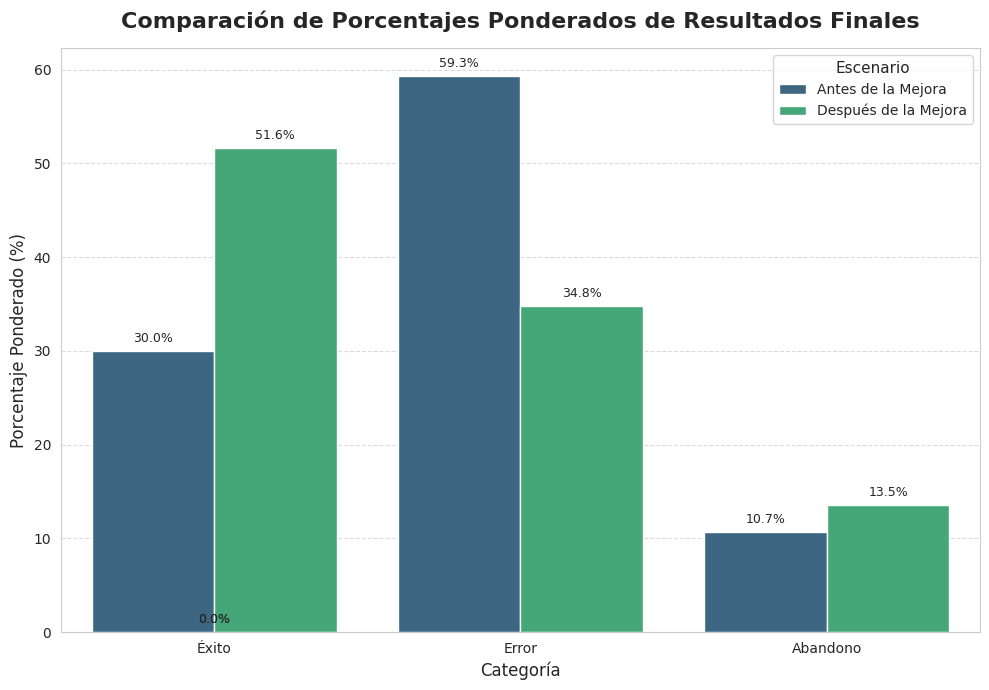

In [171]:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd

# Creamos una tabla comparativa con los porcentajes de 'Antes' y 'Después' de la mejora.
df_comparacion = pd.DataFrame({
    'Antes de la Mejora': weighted_percentages,
    'Después de la Mejora': weighted_percentages_mejorados
})

# Para un gráfico de barras agrupado, es útil 'desapilar' los datos (melt).
df_comparacion_melted = df_comparacion.reset_index().melt(
    id_vars='index',
    var_name='Escenario',
    value_name='Porcentaje Ponderado'
)
df_comparacion_melted.rename(columns={'index': 'Categoría'}, inplace=True)

# Configuramos el tamaño del gráfico para que se vea bien.
fig_comp_grouped, ax_comp_grouped = plt.subplots(figsize=(10, 7))

# Creamos un gráfico de barras agrupado para comparar los escenarios.
sns.barplot(x='Categoría', y='Porcentaje Ponderado', hue='Escenario', data=df_comparacion_melted, palette='viridis', ax=ax_comp_grouped)

# Añadimos un título y etiquetas claras a los ejes.
ax_comp_grouped.set_title('Comparación de Porcentajes Ponderados de Resultados Finales', fontsize=16, fontweight='bold', pad=15)
ax_comp_grouped.set_xlabel('Categoría', fontsize=12)
ax_comp_grouped.set_ylabel('Porcentaje Ponderado (%)', fontsize=12)

# Ajustamos las etiquetas de los ejes para que sean legibles.
ax_comp_grouped.tick_params(axis='x', rotation=0, labelsize=10)
ax_comp_grouped.tick_params(axis='y', labelsize=10)

# Mostramos la leyenda para identificar qué barra es de 'Antes' y cuál de 'Después'.
ax_comp_grouped.legend(title='Escenario', title_fontsize='11', fontsize='10')

# Añadimos una cuadrícula para facilitar la lectura de los valores.
ax_comp_grouped.grid(axis='y', linestyle='--', alpha=0.7)

# Colocamos los valores exactos sobre cada barra para mayor precisión.
for p in ax_comp_grouped.patches:
    ax_comp_grouped.annotate(f"{p.get_height():.1f}%",
                           (p.get_x() + p.get_width() / 2., p.get_height()),
                           ha='center', va='center',
                           xytext=(0, 9),
                           textcoords='offset points', fontsize=9)

# Aseguramos que todo el diseño se ajuste bien y mostramos el gráfico.
plt.tight_layout()
plt.show()

### **Distribución Ponderada ANTES de la Mejora (Gráfico de Tarta)**

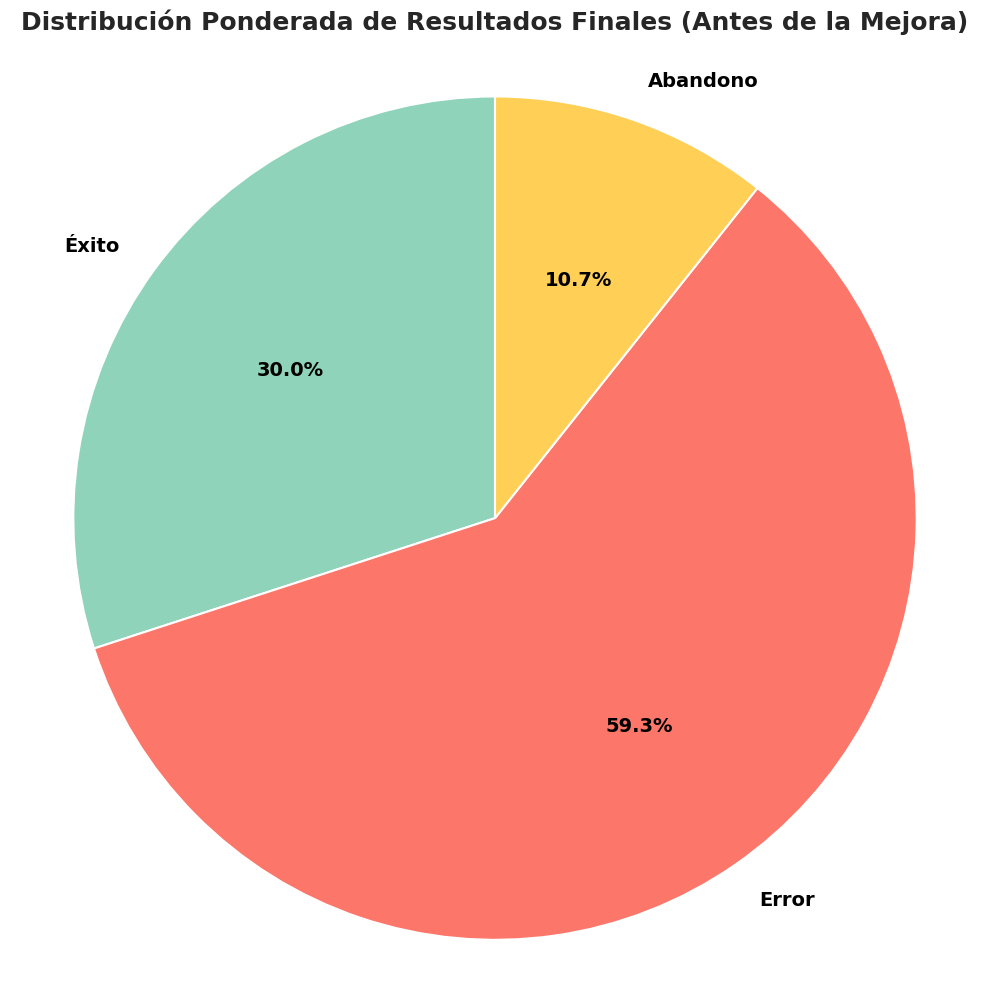

In [172]:
import matplotlib.pyplot as plt

fig_pie_before, ax_pie_before = plt.subplots(figsize=(10, 10)) # Aumentar ligeramente el tamaño

colors_before = ['#8fd3bb', '#fc766a', '#ffcf56'] # Paleta de colores más suave
explode_before = [0.05, 0.05, 0.05] # Separar un poco las rebanadas

ax_pie_before.pie(weighted_percentages.values(),
                    labels=weighted_percentages.keys(),
                    autopct='%1.1f%%',
                    startangle=90,
                    colors=colors_before,
                    wedgeprops={'edgecolor': 'white', 'linewidth': 1.5}, # Bordes blancos para las rebanadas
                    textprops={'fontsize': 14, 'color': 'black', 'fontweight': 'bold'})

ax_pie_before.set_title('Distribución Ponderada de Resultados Finales (Antes de la Mejora)', fontsize=18, fontweight='bold', pad=20) # Título más grande y espaciado
ax_pie_before.axis('equal') # Asegura que el círculo sea proporcional

plt.tight_layout()
plt.show()

### **Distribución Ponderada DESPUÉS de la Mejora (Gráfico de Tarta)**

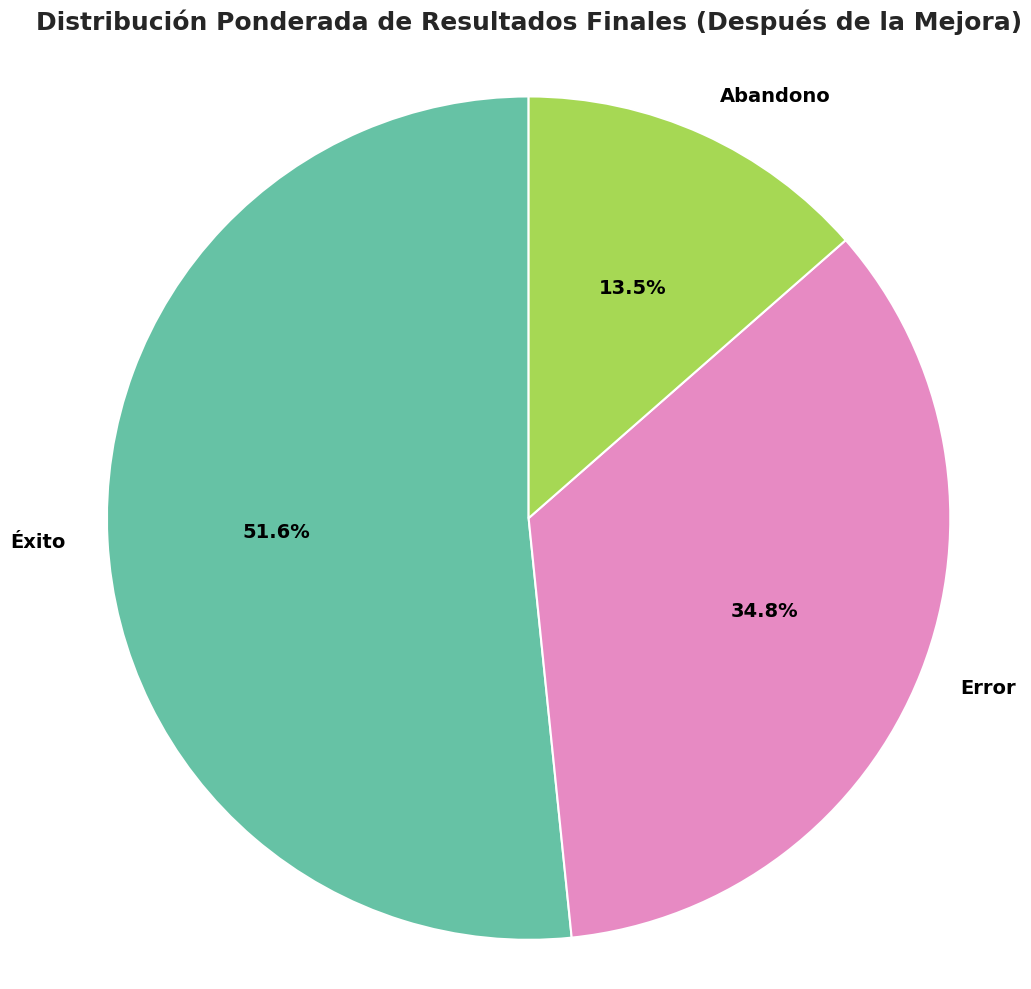

In [173]:
import matplotlib.pyplot as plt

fig_pie_after, ax_pie_after = plt.subplots(figsize=(10, 10)) # Aumentar ligeramente el tamaño

colors_after = ['#66c2a5', '#e78ac3', '#a6d854'] # Nueva paleta de colores para el escenario mejorado
explode_after = [0.05, 0.05, 0.05] # Separar un poco las rebanadas

ax_pie_after.pie(weighted_percentages_mejorados.values(),
                   labels=weighted_percentages_mejorados.keys(),
                   autopct='%1.1f%%',
                   startangle=90,
                   colors=colors_after,
                   wedgeprops={'edgecolor': 'white', 'linewidth': 1.5}, # Bordes blancos para las rebanadas
                   textprops={'fontsize': 14, 'color': 'black', 'fontweight': 'bold'})

ax_pie_after.set_title('Distribución Ponderada de Resultados Finales (Después de la Mejora)', fontsize=18, fontweight='bold', pad=20) # Título más grande y espaciado
ax_pie_after.axis('equal') # Asegura que el círculo sea proporcional

plt.tight_layout()
plt.show()

### **Visualización Comparativa de los Porcentajes Ponderados**

In [174]:
import matplotlib.pyplot as plt
import pandas as pd

# Creamos una tabla comparativa con los porcentajes de 'Antes' y 'Después' de la mejora.
df_comparacion = pd.DataFrame({
    'Antes de la Mejora': weighted_percentages,
    'Después de la Mejora': weighted_percentages_mejorados
})

# Para un gráfico de barras agrupado, es útil 'desapilar' los datos (melt).
df_comparacion_melted = df_comparacion.reset_index().melt(
    id_vars='index',
    var_name='Escenario',
    value_name='Porcentaje Ponderado'
)
df_comparacion_melted.rename(columns={'index': 'Categoría'}, inplace=True)

# Mostramos la tabla para que veas los datos con los que trabajaremos.
display(df_comparacion_melted.round(1))

,Categoría,Escenario,Porcentaje Ponderado
0,Éxito,Antes de la Mejora,30.0
1,Error,Antes de la Mejora,59.3
2,Abandono,Antes de la Mejora,10.7
3,Éxito,Después de la Mejora,51.6
4,Error,Después de la Mejora,34.8
5,Abandono,Después de la Mejora,13.5


#### **6. ¿Cuáles serían los nuevos porcentajes de éxito, error y abandono después de la intervención?**

Una vez implementadas las mejoras en la autenticación, los porcentajes ponderados de los resultados finales se ajustarían de la siguiente manera:
*   El **Éxito** alcanzaría aproximadamente el **51.6%**, mostrando una mejora considerable.
*   El **Error** se reduciría a cerca del **34.8%**, lo que indica una disminución significativa en los obstáculos.
*   Y el **Abandono** se situaría alrededor del **13.5%**, un ligero aumento que se ve justificado por el gran salto en la tasa de éxito.
Estos nuevos valores reflejan un escenario mucho más favorable para la experiencia del usuario y la efectividad del sistema.